<a href="https://colab.research.google.com/github/fernandovidalnn/evaluacion_1_mineria_datos/blob/main/ev3_spotify_mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación 3 - Minería de Datos / Machine Learning

## Proyecto: Análisis y modelamiento de canciones de Spotify

### Integrantes:
- Fernando Vidal
- Matías Gallardo

### Fuente de datos:
Dataset Spotify Music obtenido desde Kaggle:  
https://www.kaggle.com/datasets/anbudanadithya/spotify-music

### Objetivo general:
Analizar un conjunto de datos de canciones de Spotify mediante técnicas de minería de datos, análisis exploratorio, visualización y modelos de Machine Learning, con el fin de identificar patrones relacionados con la popularidad musical y apoyar la toma de decisiones mediante un dashboard.

In [1]:
# Librerías principales para manejo de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para preprocesamiento
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder

# Librerías para división de datos
from sklearn.model_selection import train_test_split

# Librerías para modelos de Machine Learning
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# Librerías para métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

# Configuración visual
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## 2. Carga del dataset

En esta sección se carga el archivo CSV correspondiente al dataset de canciones de Spotify. Luego se revisa su tamaño inicial y las primeras filas para comprender su estructura.

In [4]:
df = pd.read_csv('Spotify_Music.csv')

df.shape

(114000, 20)

In [5]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
df.tail()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,CesÃ¡ria Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,2hETkH7cOfqmz3LqZDHZf5,CesÃ¡ria Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


El dataset contiene registros de canciones de Spotify y distintas características asociadas a cada canción. Entre las variables se encuentran datos de identificación, información del artista, álbum, nombre de canción, popularidad, duración, características musicales y género.

## 3. Comprensión inicial de los datos

A continuación se revisan los nombres de las columnas, los tipos de datos y la cantidad de valores nulos presentes en el dataset. Esto permite identificar variables numéricas, categóricas y posibles problemas de calidad de datos.

In [7]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [8]:
df.dtypes

,0
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [10]:
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


Se observa que el dataset presenta muy pocos valores nulos en comparación con la cantidad total de registros. Las columnas con valores nulos son revisadas antes de aplicar la limpieza correspondiente.

## 4. Limpieza de datos

Debido a que la cantidad de valores nulos es mínima, se decide eliminar las filas que contienen datos faltantes. Esta decisión no afecta significativamente el tamaño del dataset y permite trabajar con datos completos.

In [11]:
df = df.dropna()
df.shape

(113999, 20)

In [12]:
df.isnull().sum()

,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


Después de aplicar la limpieza, el dataset queda sin valores nulos, manteniendo prácticamente la totalidad de los registros originales.

## 5. Mapeo de variables

A continuación se presenta el mapeo de las variables del dataset, clasificándolas según su tipo analítico.

| Variable | Descripción | Tipo |
|---|---|---|
| Unnamed: 0 | Índice original del dataset | Numérica discreta |
| track_id | Identificador único de la canción | Categórica nominal |
| artists | Nombre del artista | Categórica nominal |
| album_name | Nombre del álbum | Categórica nominal |
| track_name | Nombre de la canción | Categórica nominal |
| popularity | Popularidad de la canción de 0 a 100 | Numérica discreta |
| duration_ms | Duración en milisegundos | Numérica continua |
| explicit | Indica si la canción es explícita | Categórica binaria |
| danceability | Nivel de bailabilidad | Numérica continua |
| energy | Nivel de energía | Numérica continua |
| key | Tonalidad musical | Categórica nominal |
| loudness | Volumen en decibeles | Numérica continua |
| mode | Escala musical: mayor o menor | Categórica binaria |
| speechiness | Presencia de voz hablada | Numérica continua |
| acousticness | Nivel acústico | Numérica continua |
| instrumentalness | Probabilidad de ser instrumental | Numérica continua |
| liveness | Presencia de público o grabación en vivo | Numérica continua |
| valence | Positividad musical | Numérica continua |
| tempo | Ritmo en BPM | Numérica continua |
| time_signature | Compás musical | Categórica discreta |
| track_genre | Género musical | Categórica nominal |

## 6. Revisión de valores únicos

Se revisa la cantidad de valores únicos por columna para identificar variables de alta cardinalidad, variables binarias y variables categóricas relevantes para el análisis.

In [13]:
df.nunique().sort_values(ascending=False)

,0
track_id,89740
track_name,73602
duration_ms,50696
album_name,46579
tempo,45652
artists,31437
loudness,19480
instrumentalness,5346
acousticness,5061
energy,2083


In [14]:
df.describe(include='all')

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,113999,113999,113999,113999,113999.000000,1.139990e+05,113999,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999
unique,89740,31437,46579,73602,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acoustic
freq,9,279,195,151,NaN,NaN,104252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000
mean,NaN,NaN,NaN,NaN,33.238827,2.280312e+05,NaN,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034,NaN
std,NaN,NaN,NaN,NaN,22.304959,1.072961e+05,NaN,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623,NaN
min,NaN,NaN,NaN,NaN,0.000000,8.586000e+03,NaN,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,17.000000,1.740660e+05,NaN,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000,NaN
50%,NaN,NaN,NaN,NaN,35.000000,2.129060e+05,NaN,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,NaN
75%,NaN,NaN,NaN,NaN,50.000000,2.615060e+05,NaN,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000,NaN


In [15]:
df['explicit'].value_counts()

,count
explicit,
False,104252
True,9747


In [16]:
df['mode'].value_counts()

,count
mode,
1,72681
0,41318


In [17]:
df['track_genre'].value_counts().head(10)

,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
anime,1000
black-metal,1000
bluegrass,1000
blues,1000


In [18]:
df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

,popularity
track_genre,
pop-film,59.283000
k-pop,56.952953
chill,53.651000
sad,52.379000
grunge,49.594000
...,...
chicago-house,12.339000
detroit-techno,11.174000
latin,8.297000


# Análisis Exploratorio de Datos (EDA)

Una vez comprendida la estructura del conjunto de datos, se procede al análisis exploratorio mediante visualizaciones. El objetivo es identificar patrones, distribuciones, relaciones entre variables y posibles valores atípicos que permitan comprender mejor el comportamiento del dataset.

array([[<Axes: title={'center': 'popularity'}>,
        <Axes: title={'center': 'duration_ms'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>],
       [<Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'speechiness'}>],
       [<Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'valence'}>],
       [<Axes: title={'center': 'tempo'}>,
        <Axes: title={'center': 'time_signature'}>, <Axes: >, <Axes: >]],
      dtype=object)

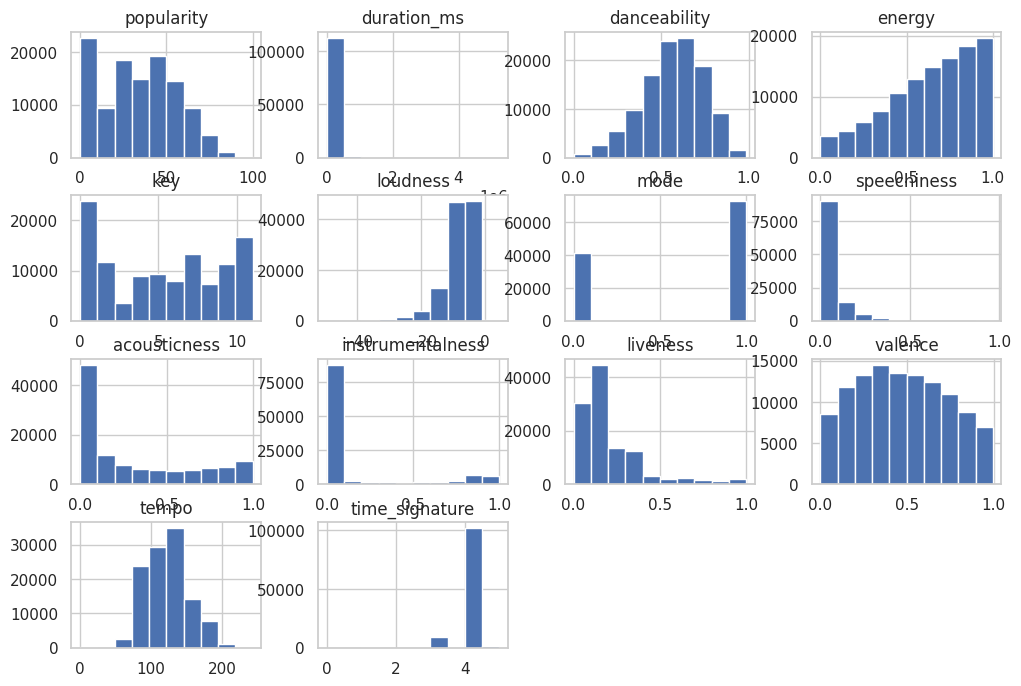

In [19]:
df.hist(figsize=(12,8))

El análisis de histogramas muestra que la mayoría de las variables presentan distribuciones concentradas en rangos específicos, evidenciando patrones claros en las características musicales del dataset.

En general predominan canciones vocales (se deduce de *speechiness* e *instrumentalness*), energéticas (desde *energy*) y con ritmos moderados (desde *tempo*), con presencia de valores atípicos principalmente en la duración (*duration_ms*).

In [23]:
cols_numericas = [
    'popularity',
    'duration_ms',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

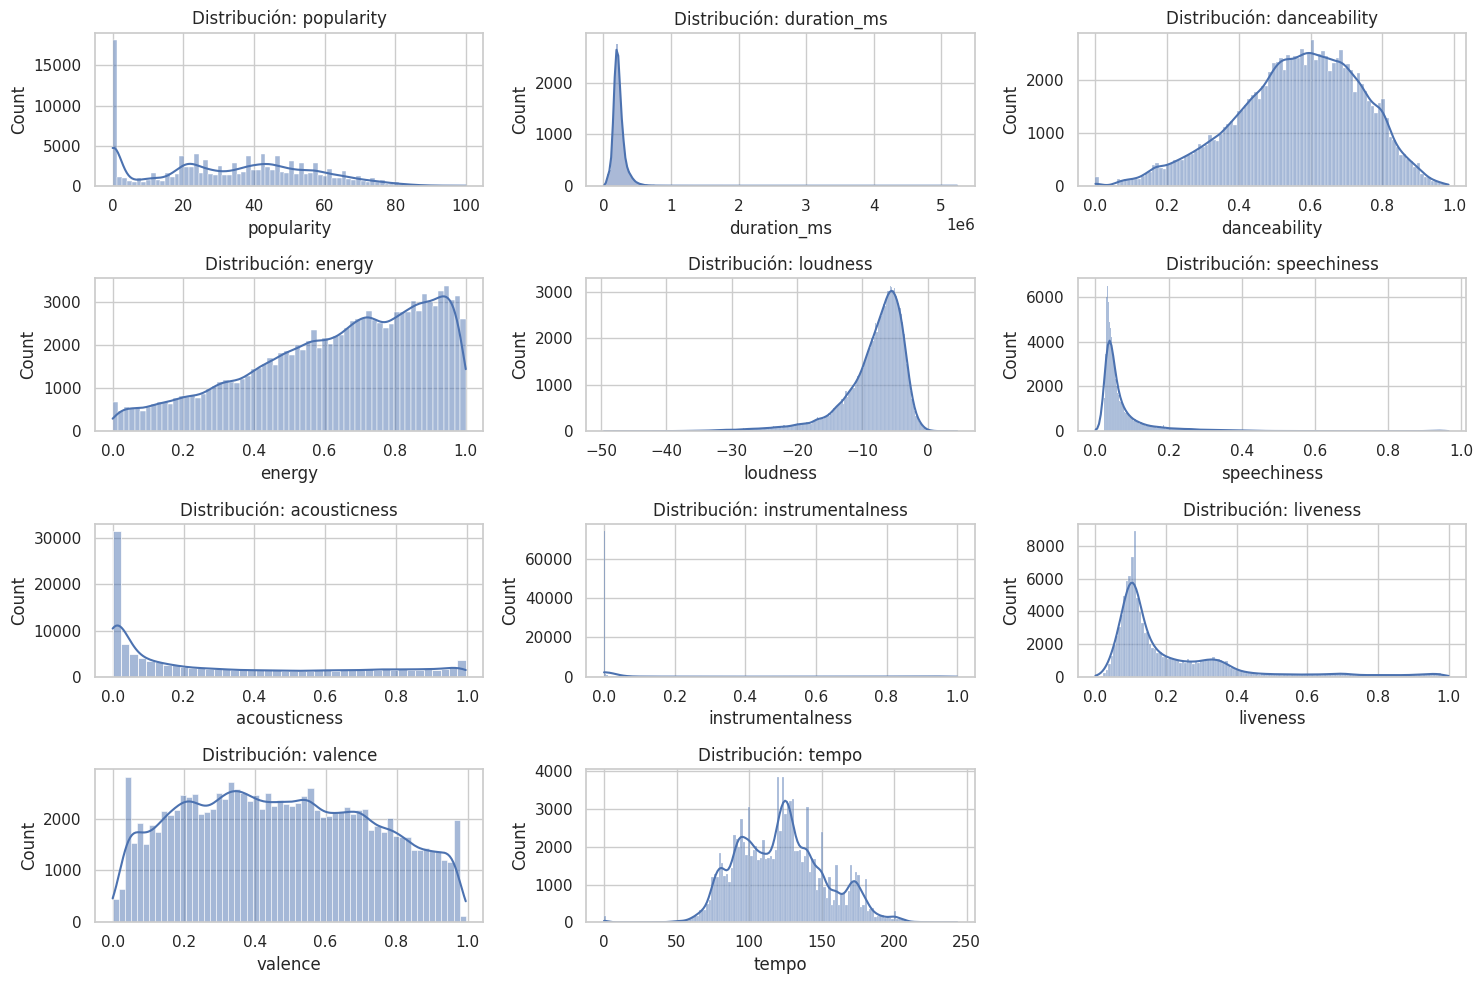

In [24]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(4,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución: {col}')

plt.tight_layout()
plt.show()

### Patrones

- Se observa claramente en **energy** una tendencia hacia valores altos.
- **danceability** presenta una distribución cercana a una distribución normal.
- **tempo** muestra una concentración aproximada entre 100 y 140 BPM.

Estos resultados evidencian patrones claros en el comportamiento de las canciones.

### Concentración de datos

- **speechiness** se concentra cerca de 0.
- **instrumentalness** presenta la mayoría de sus valores cercanos a 0.
- **acousticness** muestra una fuerte acumulación en valores bajos.

Esto permite identificar dónde se concentra la mayor parte de los datos.

### Valores atípicos

En **duration_ms** se observa una cola larga hacia la derecha, lo que indica la presencia de canciones con una duración considerablemente mayor al promedio.

En general, el análisis de histogramas evidencia que predominan canciones con baja presencia de voz hablada, poca instrumentalidad, alta energía y ritmos moderados.

## Detección de valores atípicos (Outliers)

Los diagramas de caja (Boxplots) permiten visualizar la distribución de las variables numéricas, identificando la mediana, el rango intercuartílico y los posibles valores atípicos presentes en el conjunto de datos.

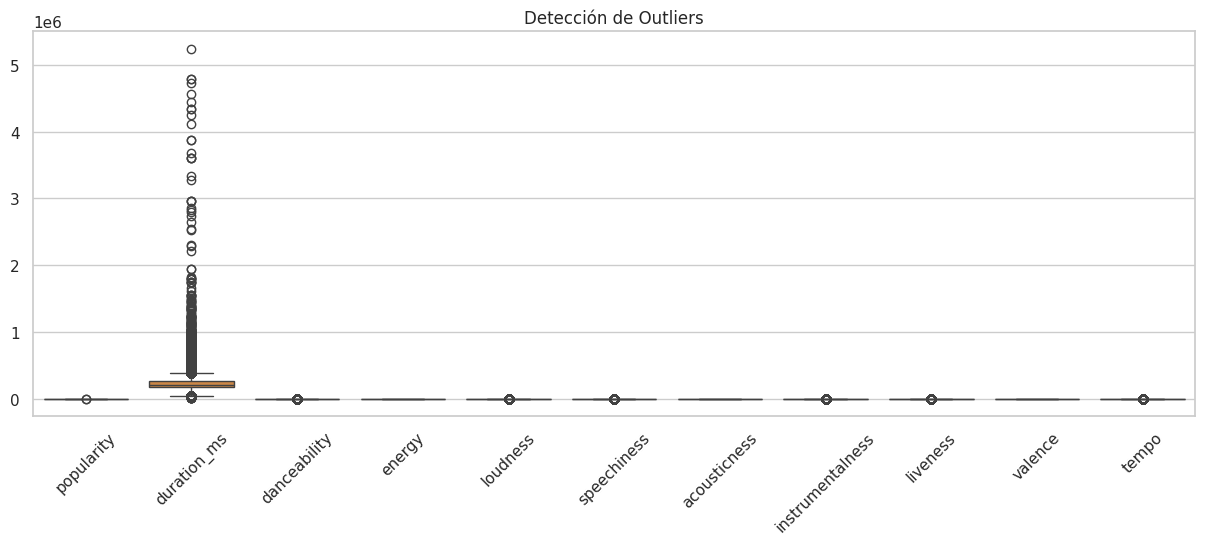

In [25]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df[cols_numericas])
plt.xticks(rotation=45)
plt.title('Detección de Outliers')
plt.show()

La variable **duration_ms** presenta numerosos valores atípicos y una escala considerablemente mayor que el resto de las variables, lo que dificulta la visualización de los demás diagramas de caja.

Por esta razón, se realizará un nuevo análisis excluyendo esta variable, con el objetivo de obtener una mejor interpretación del comportamiento del resto de las características numéricas.

In [26]:
cols_sin_duration = [col for col in cols_numericas if col != 'duration_ms']

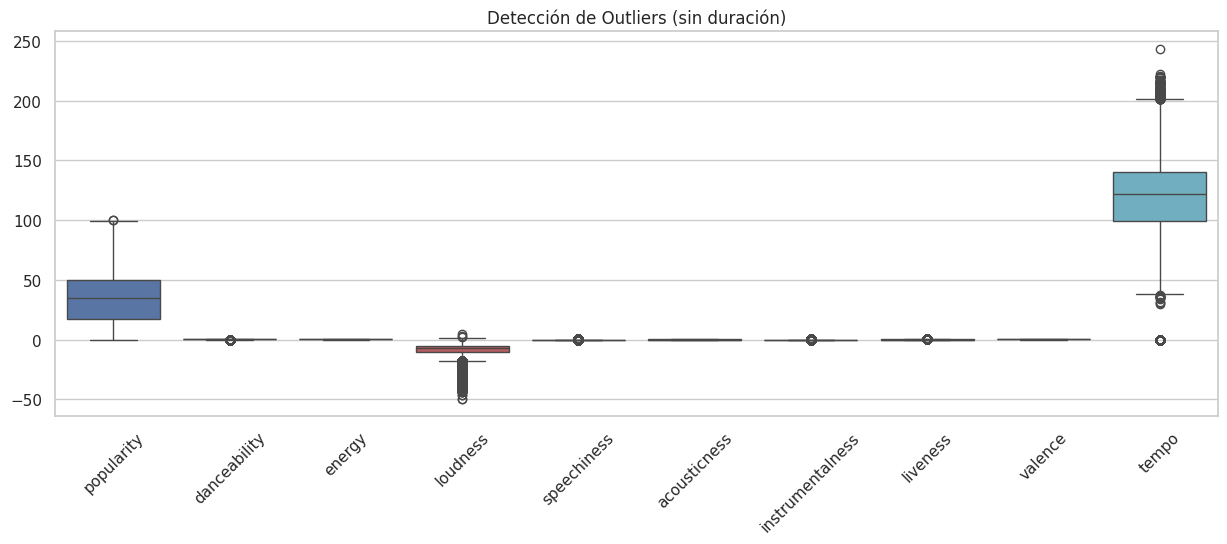

In [27]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df[cols_sin_duration])
plt.xticks(rotation=45)
plt.title('Detección de Outliers (sin duración)')
plt.show()

Al excluir la variable **duration_ms**, es posible observar con mayor claridad la distribución y dispersión del resto de las variables.

En general, las variables presentan una distribución relativamente estable y concentrada, aunque aún se observan algunos valores atípicos principalmente en **loudness** y **tempo**.

Para analizar con mayor detalle cada variable, se presentan a continuación los diagramas de caja de forma individual.

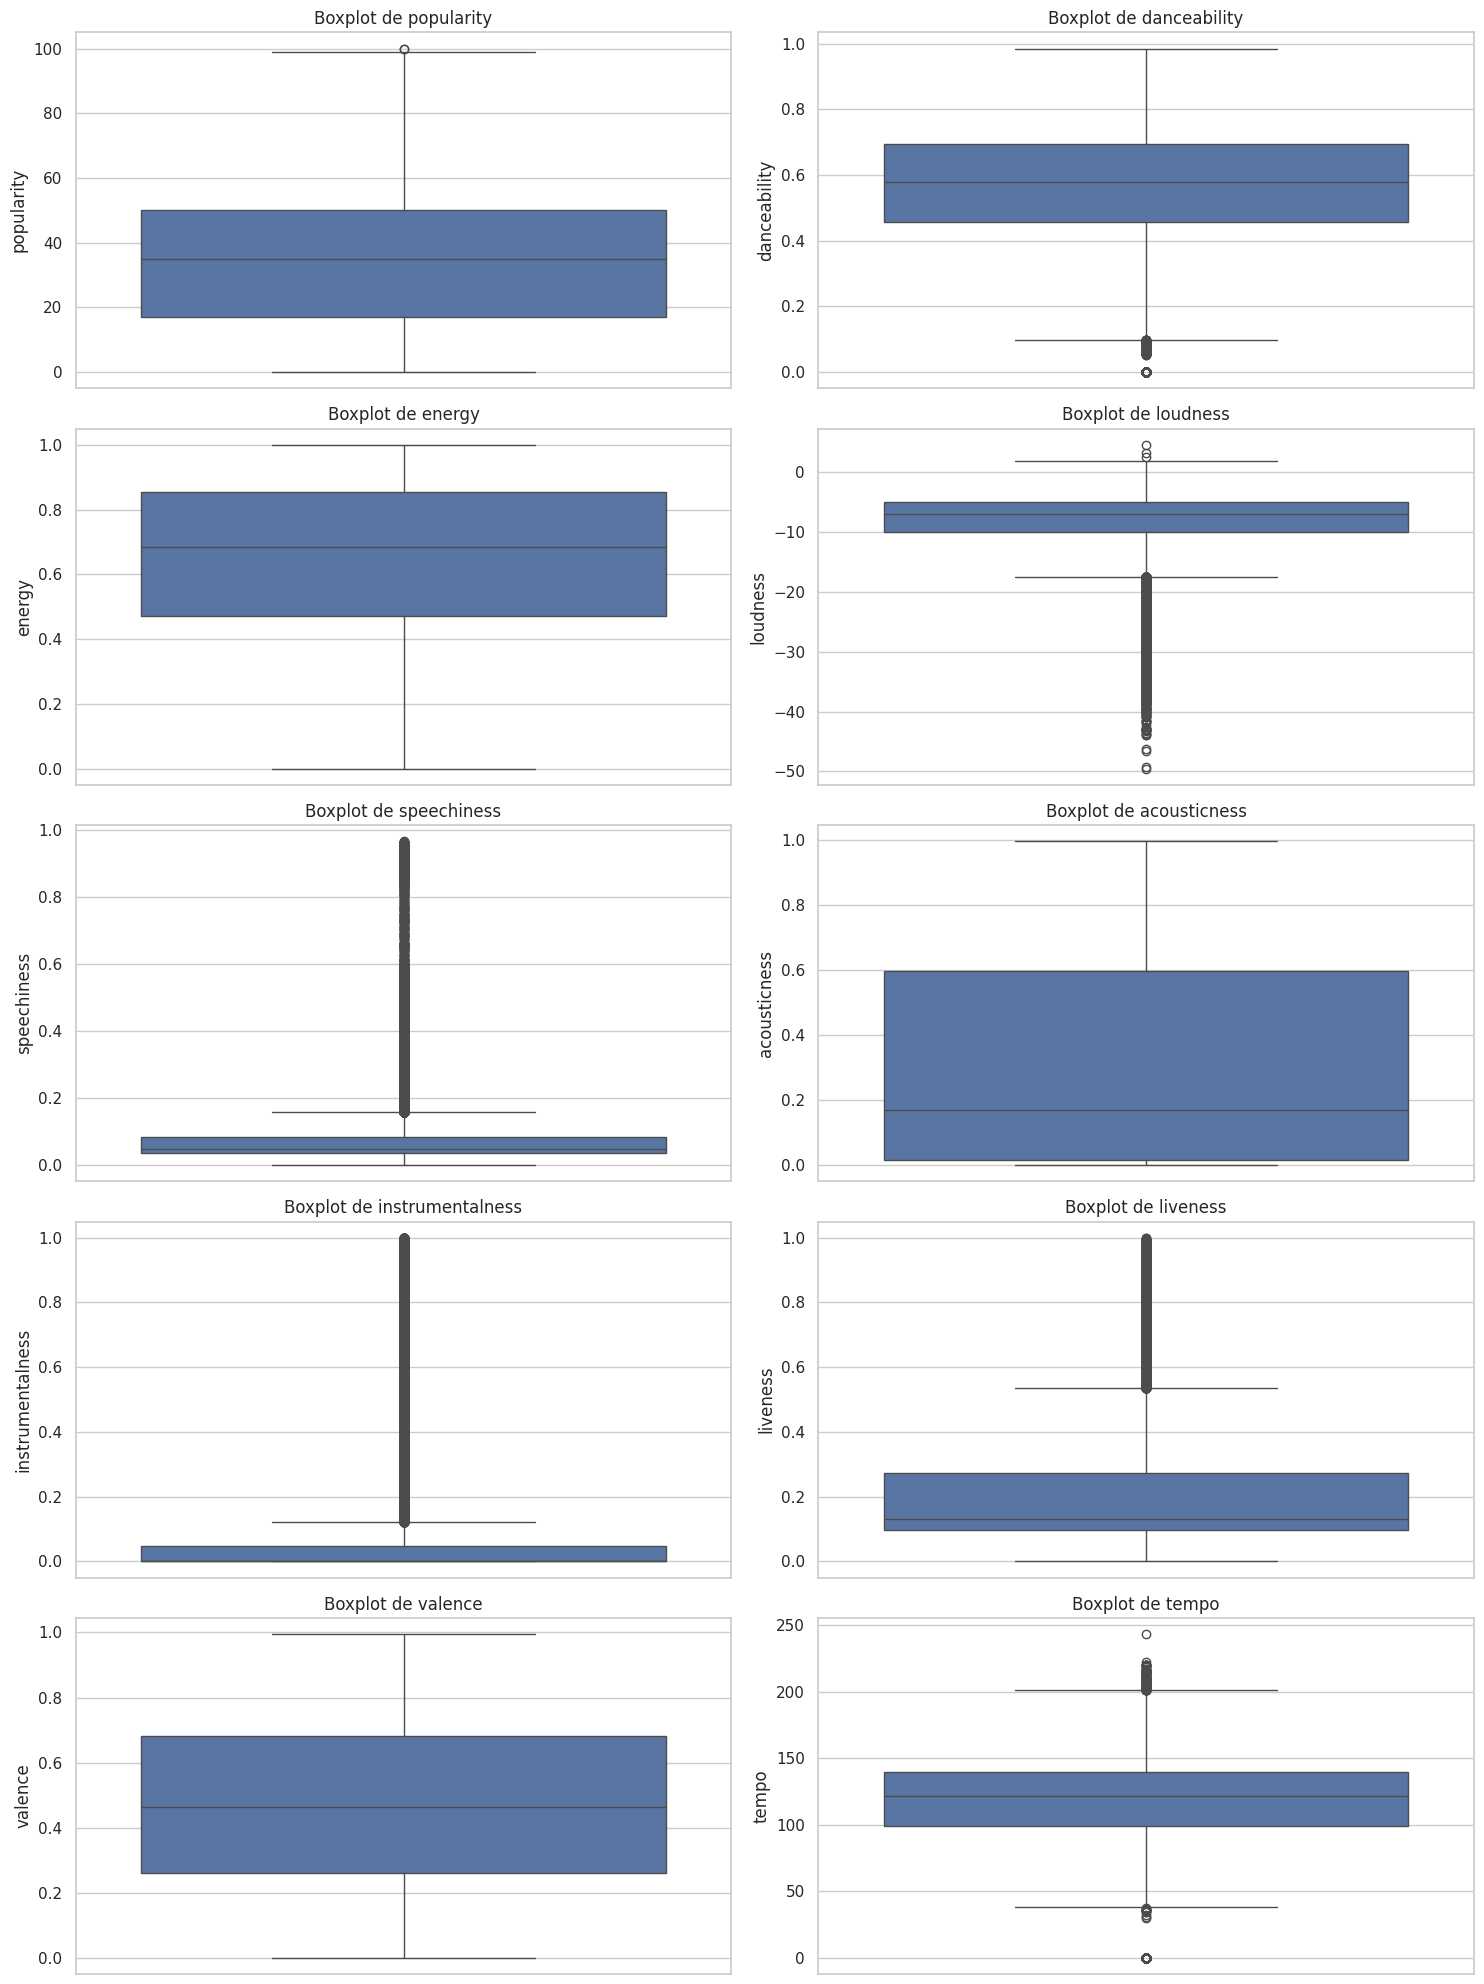

In [28]:
plt.figure(figsize=(15,20))

for i, col in enumerate(cols_sin_duration, 1):
    plt.subplot(5,2,i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

El análisis de los diagramas de caja individuales evidencia que variables como **speechiness**, **instrumentalness** y **acousticness** presentan distribuciones sesgadas hacia valores bajos, indicando el predominio de canciones vocales y no instrumentales.

Por otro lado, variables como **danceability**, **energy** y **valence** muestran distribuciones más equilibradas, reflejando una mayor variabilidad en estas características musicales.

Asimismo, se observan valores atípicos en variables como **loudness** y **tempo**, lo que evidencia diversidad en la intensidad sonora y el ritmo de las canciones.

En general, los valores atípicos detectados corresponden a la naturaleza del conjunto de datos y no necesariamente representan errores de registro.

## Relación entre variables y popularidad

En esta sección se analiza la relación entre la popularidad de las canciones y distintas características musicales. El objetivo es identificar si variables como energía, duración, bailabilidad, tempo o contenido explícito presentan algún comportamiento asociado al nivel de popularidad.

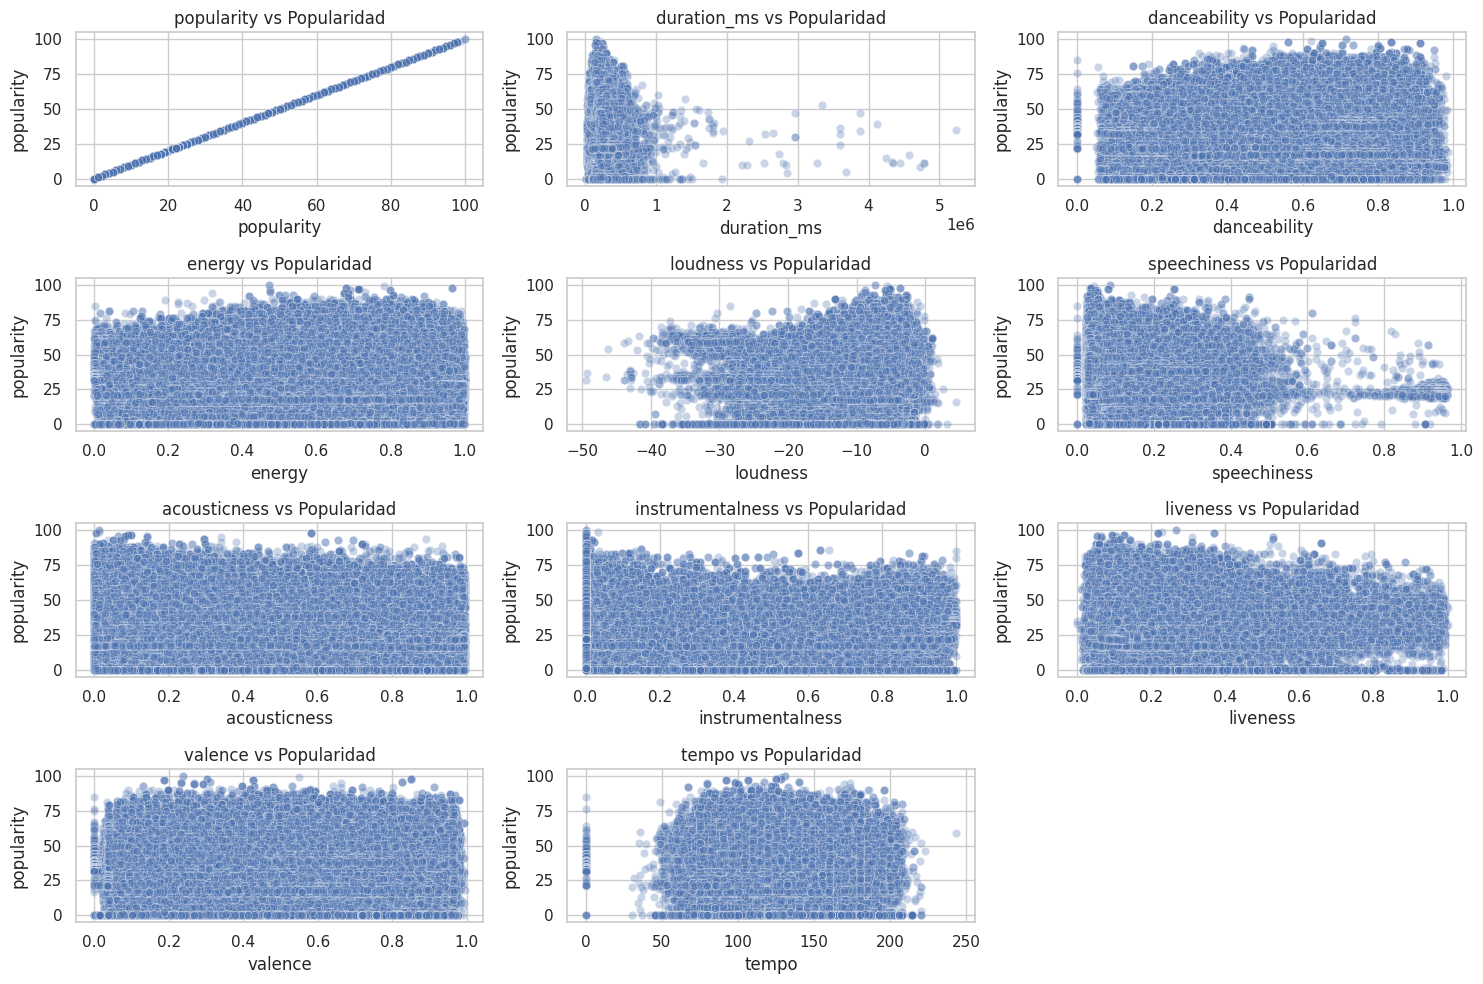

In [29]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(4,3,i)
    sns.scatterplot(x=df[col], y=df['popularity'], alpha=0.3)
    plt.title(f'{col} vs Popularidad')

plt.tight_layout()
plt.show()

Los gráficos de dispersión permiten observar la relación entre cada variable numérica y la popularidad de las canciones.

En general, no se observa una relación lineal clara entre las características musicales y la popularidad. Variables como **danceability**, **energy**, **valence** y **tempo** se distribuyen a lo largo de distintos niveles de popularidad, sin mostrar una tendencia marcada.

Esto sugiere que la popularidad no depende de una sola característica musical, sino de una combinación de factores y posiblemente de elementos externos al dataset, como el artista, tendencias, marketing o contexto cultural.

## 7.3 Popularidad según variables categóricas relevantes

A continuación se analiza la popularidad considerando variables categóricas como el género musical y el contenido explícito.

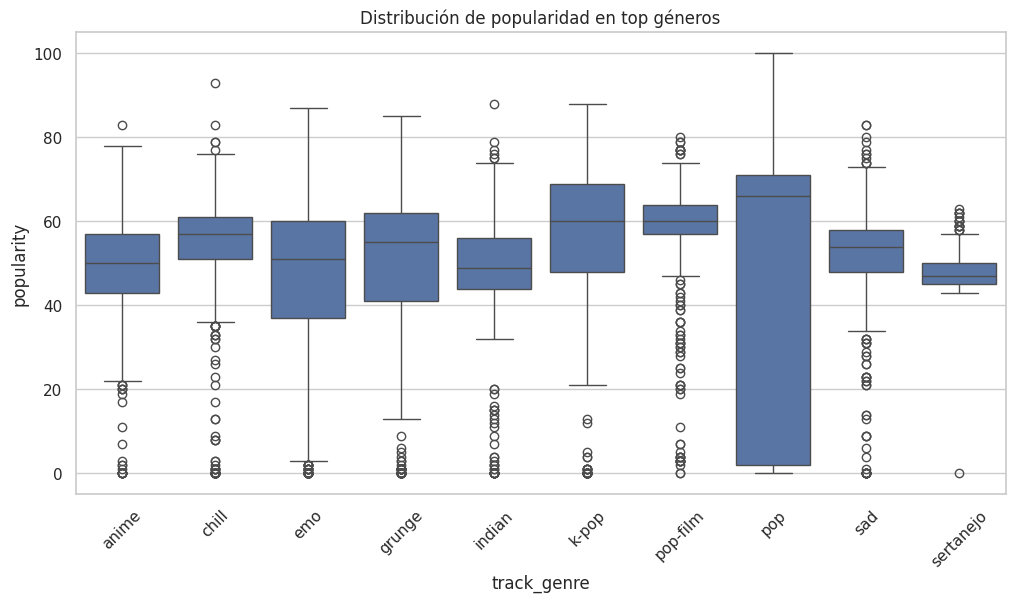

In [30]:
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
top_genres = genre_popularity.head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df[df['track_genre'].isin(top_genres)],
    x='track_genre',
    y='popularity'
)

plt.xticks(rotation=45)
plt.title('Distribución de popularidad en top géneros')
plt.show()

El diagrama de cajas muestra la distribución de la popularidad en los géneros con mayor promedio de popularidad.

Se observan diferencias entre géneros, especialmente en la mediana y dispersión de los datos. Géneros como **pop-film**, **k-pop**, **chill** y **sad** presentan niveles de popularidad más altos en comparación con otros géneros.

Sin embargo, también existe variabilidad dentro de cada género, lo que indica que el género musical influye en la popularidad, pero no la determina completamente por sí solo.

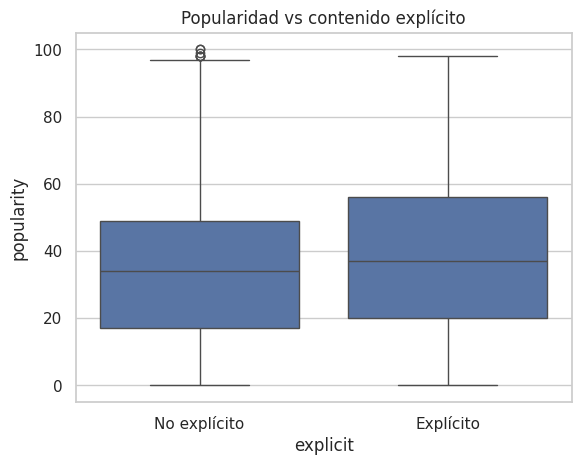

In [31]:
sns.boxplot(x=df['explicit'], y=df['popularity'])
plt.title('Popularidad vs contenido explícito')
plt.xticks([0,1], ['No explícito', 'Explícito'])
plt.show()

Al comparar canciones explícitas y no explícitas, se observa que ambas categorías presentan distribuciones bastante similares.

Aunque las canciones explícitas pueden mostrar una leve diferencia en la mediana de popularidad, esta diferencia no es lo suficientemente marcada como para afirmar que el contenido explícito determine directamente la popularidad de una canción.

## 7.4 Distribución de variables relevantes

A continuación se analizan dos variables musicales relevantes: el tempo y la energía. Estas permiten comprender el comportamiento general del conjunto de datos respecto al ritmo y la intensidad de las canciones.

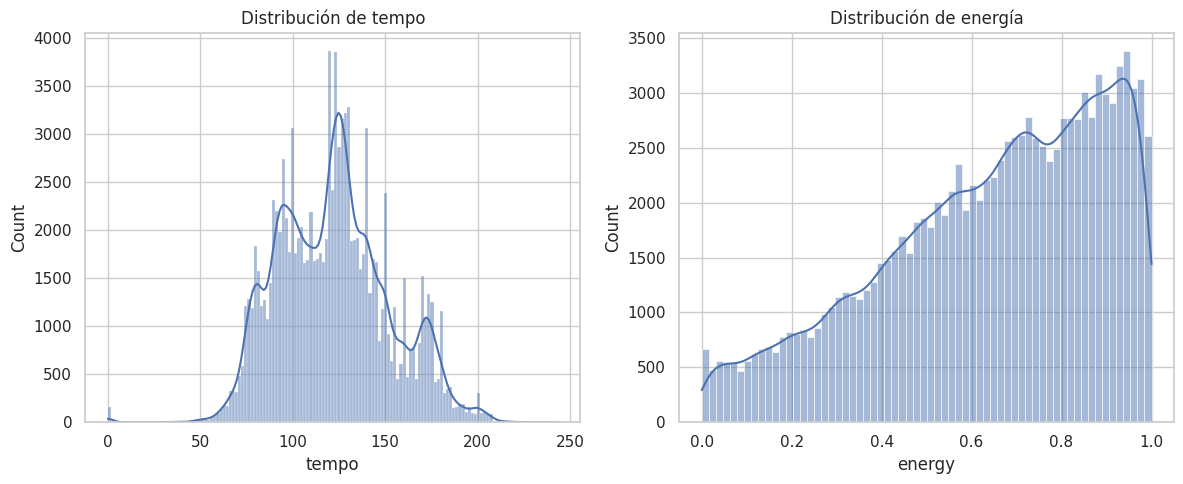

In [32]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['tempo'], kde=True)
plt.title('Distribución de tempo')

plt.subplot(1,2,2)
sns.histplot(df['energy'], kde=True)
plt.title('Distribución de energía')

plt.tight_layout()
plt.show()

La mayoría de las canciones presenta un tempo concentrado entre 100 y 150 BPM, lo que corresponde a ritmos moderados.

Por otra parte, la variable **energy** muestra una mayor concentración en valores altos, indicando que predominan canciones con una intensidad musical elevada.

## 7.5 Relación entre variables musicales

El siguiente gráfico permite visualizar simultáneamente la relación entre distintas variables numéricas del conjunto de datos.

In [ ]:
sns.pairplot(
    df[['energy',
        'danceability',
        'valence',
        'tempo',
        'loudness']].sample(500),
    corner=True
)

plt.show()

El análisis evidencia que la mayoría de las variables presentan relaciones débiles entre sí.

La relación más evidente corresponde a **energy** y **loudness**, donde canciones con mayor energía suelen presentar un volumen más alto. En el resto de las variables no se observan correlaciones lineales importantes.

<Axes: xlabel='key', ylabel='popularity'>

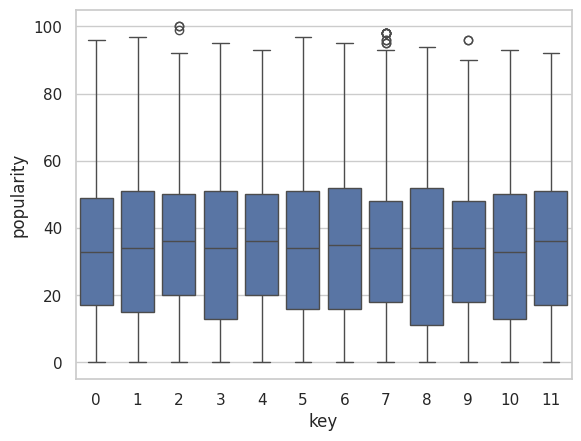

In [33]:
sns.boxplot(x=df['key'], y=df['popularity'])

<Axes: xlabel='mode', ylabel='popularity'>

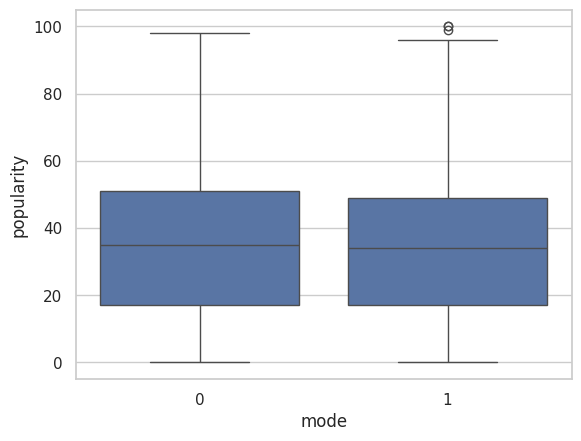

In [34]:
sns.boxplot(x=df['mode'], y=df['popularity'])

<Axes: xlabel='time_signature', ylabel='popularity'>

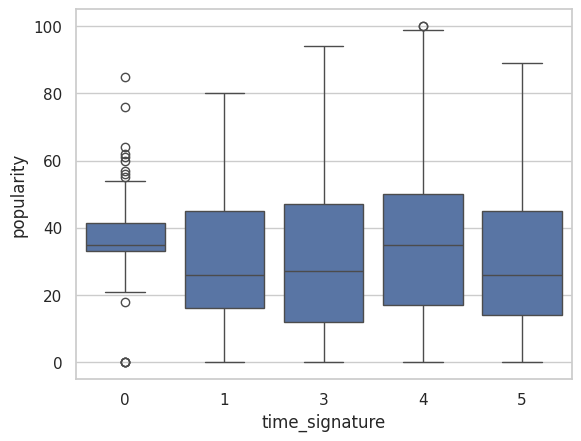

In [35]:
sns.boxplot(x=df['time_signature'], y=df['popularity'])

# Matriz de correlación

La matriz de correlación permite analizar la relación lineal entre las variables numéricas del conjunto de datos. Para ello, primero se estandarizan las variables utilizando StandardScaler, evitando que las diferencias de escala afecten la comparación entre ellas.

# Preparación de datos para Machine Learning

Antes de aplicar modelos de Machine Learning, se prepara una copia del dataset original limpio. En esta etapa se eliminan columnas que no aportan al modelamiento y se transforman variables categóricas mediante One Hot Encoding.

In [36]:
df_model = df.copy().reset_index(drop=True)

Se crea una copia del dataset limpio para no modificar el dataframe original utilizado en el análisis exploratorio.

In [40]:
df_model = df_model.drop(columns=[
    'track_id',
    'artists',
    'album_name',
    'track_name'
])

In [41]:
df_model['explicit'] = df_model['explicit'].astype(int)

In [42]:
from sklearn.preprocessing import OneHotEncoder

ohe_genre = OneHotEncoder(drop='first', sparse_output=False)

encoded_genre = ohe_genre.fit_transform(df_model[['track_genre']])

encoded_genre_df = pd.DataFrame(
    encoded_genre,
    columns=ohe_genre.get_feature_names_out(['track_genre'])
)

df_model = pd.concat(
    [
        df_model.drop('track_genre', axis=1).reset_index(drop=True),
        encoded_genre_df.reset_index(drop=True)
    ],
    axis=1
)

In [43]:
df_model.shape

(113999, 128)

In [44]:
df_model.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

Se transformaron las variables categóricas a formato numérico. La variable **explicit** se convirtió a valores 0 y 1, mientras que **track_genre** fue codificada mediante One Hot Encoding. Con esto, el dataset queda preparado para aplicar modelos de Machine Learning.